# ROSIE Output Visualization

This notebook visualizes multiplex protein expression predictions from ROSIE model outputs.
Outputs are **50-channel TIFF** files in `output/` folder (one channel per biomarker).

**Includes:** Input H&E (ground truth source), optional multiplex GT, and ROSIE predictions side-by-side.

**Channel order** (from README): DAPI, CD45, CD68, CD14, PD1, FoxP3, CD8, HLA-DR, PanCK, CD3e, CD4, aSMA, CD31, Vimentin, CD45RO, Ki67, CD20, CD11c, Podoplanin, PDL1, GranzymeB, CD38, CD141, CD21, CD163, BCL2, LAG3, EpCAM, CD44, ICOS, GATA3, Gal3, CD39, CD34, TIGIT, ECad, CD40, VISTA, HLA-A, MPO, PCNA, ATM, TP63, IFNg, Keratin8/18, IDO1, CD79a, HLA-E, CollagenIV, CD66

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from PIL import Image

# Paths
ROSIE_DIR = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/rosie"
OUTPUT_DIR = os.path.join(ROSIE_DIR, "output")
INPUT_DIR = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke_classification_head/test/images"
GT_DIR = None  # Set to path if you have ground-truth multiplex TIFFs (e.g. "./ground_truth/")

# 50 biomarkers in channel order (from README)
BIOMARKERS = [
    "DAPI", "CD45", "CD68", "CD14", "PD1", "FoxP3", "CD8", "HLA-DR", "PanCK", "CD3e",
    "CD4", "aSMA", "CD31", "Vimentin", "CD45RO", "Ki67", "CD20", "CD11c", "Podoplanin", "PDL1",
    "GranzymeB", "CD38", "CD141", "CD21", "CD163", "BCL2", "LAG3", "EpCAM", "CD44", "ICOS",
    "GATA3", "Gal3", "CD39", "CD34", "TIGIT", "ECad", "CD40", "VISTA", "HLA-A", "MPO",
    "PCNA", "ATM", "TP63", "IFNg", "Keratin8/18", "IDO1", "CD79a", "HLA-E", "CollagenIV", "CD66",
]


In [ ]:
def load_rosie_tiff(path):
    """Load a ROSIE TIFF output. Returns array of shape (50, H, W)."""
    data = tifffile.imread(path)
    if data.ndim == 3 and data.shape[-1] == 50:
        data = np.moveaxis(data, -1, 0)
    elif data.ndim == 3 and data.shape[0] != 50:
        data = np.moveaxis(data, 2, 0)
    return data

def normalize_channel(ch, p_low=1, p_high=99.5):
    """Normalize a single channel for display using percentiles."""
    vmin = np.percentile(ch, p_low)
    vmax = np.percentile(ch, p_high)
    if vmax <= vmin:
        return np.zeros_like(ch, dtype=np.float32)
    return np.clip((ch.astype(float) - vmin) / (vmax - vmin), 0, 1)

def rosie_name_to_input(rosie_fname):
    """Convert ROSIE output name to input H&E name. e.g. X_256_256_ROSIE.tiff -> X_256_256.png"""
    base = rosie_fname.replace("_ROSIE.tiff", "")
    return base + ".png"

def load_he_image(rosie_fname):
    """Load the corresponding H&E input image for a ROSIE output. Returns RGB array or None."""
    he_fname = rosie_name_to_input(os.path.basename(rosie_fname))
    he_path = os.path.join(INPUT_DIR, he_fname)
    if not os.path.exists(he_path):
        return None
    img = np.array(Image.open(he_path).convert("RGB"))
    return img / 255.0  # [0,1]

def load_gt_tiff(rosie_fname):
    """Load optional ground-truth multiplex TIFF. Expects {base}_GT.tiff or similar."""
    if not GT_DIR:
        return None
    base = os.path.basename(rosie_fname).replace("_ROSIE.tiff", "")
    for suffix in ["_GT.tiff", "_gt.tiff", "_CODEX.tiff"]:
        gt_path = os.path.join(GT_DIR, base + suffix)
        if os.path.exists(gt_path):
            return load_rosie_tiff(gt_path)
    return None

# List available outputs
tiff_files = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith("_ROSIE.tiff")])
tiff_path = os.path.join(OUTPUT_DIR, tiff_files[0]) if tiff_files else None
print(f"Found {len(tiff_files)} ROSIE outputs in {OUTPUT_DIR}")
print("Sample:", tiff_files[0] if tiff_files else "None")

Found 15 ROSIE outputs in /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/rosie/output
Sample: TCGA-A2-A0CV-01Z-00-DX1_2_256_256_ROSIE.tiff


## 1. Single Marker (grayscale)

View one biomarker at a time. Shows **H&E input | ROSIE pred** (and optional multiplex GT if available).

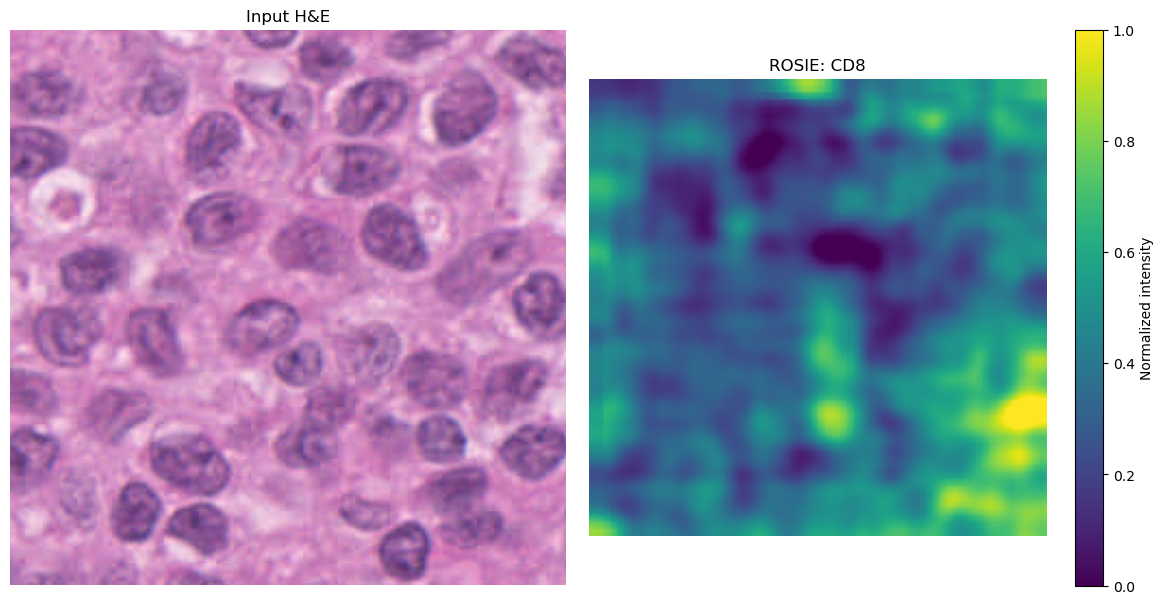

In [ ]:
# Single marker: change these to explore
# tiff_path = os.path.join(OUTPUT_DIR, tiff_files[2])  # optionally pick another file
channel_idx = 6   # CD8 (channel 0 = DAPI, 6 = CD8)
colormap = "viridis"  # or "hot", "magma", "inferno", "gray"

assert tiff_path, "No TIFF files found in output folder"
data = load_rosie_tiff(tiff_path)
ch = normalize_channel(data[channel_idx])
he_img = load_he_image(tiff_path)
gt_data = load_gt_tiff(tiff_path)

# Build subplot list: [H&E, Pred, (GT if available)]
ncols = 2 + (1 if gt_data is not None else 0)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))
axes = np.atleast_1d(axes)

axes[0].imshow(he_img if he_img is not None else np.zeros((*ch.shape, 3)))
axes[0].set_title("Input H&E")
axes[0].axis("off")

im = axes[1].imshow(ch, cmap=colormap)
axes[1].set_title(f"ROSIE: {BIOMARKERS[channel_idx]}")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="Normalized intensity")

if gt_data is not None:
    gt_ch = normalize_channel(gt_data[channel_idx])
    axes[2].imshow(gt_ch, cmap=colormap)
    axes[2].set_title(f"Ground truth: {BIOMARKERS[channel_idx]}")
    axes[2].axis("off")
plt.tight_layout()
plt.show()

## 2. RGB Composite (best for multiplex IF)

Overlay 3 biomarkers as Red, Green, Blue. Shows **H&E | ROSIE RGB** (and optional GT).

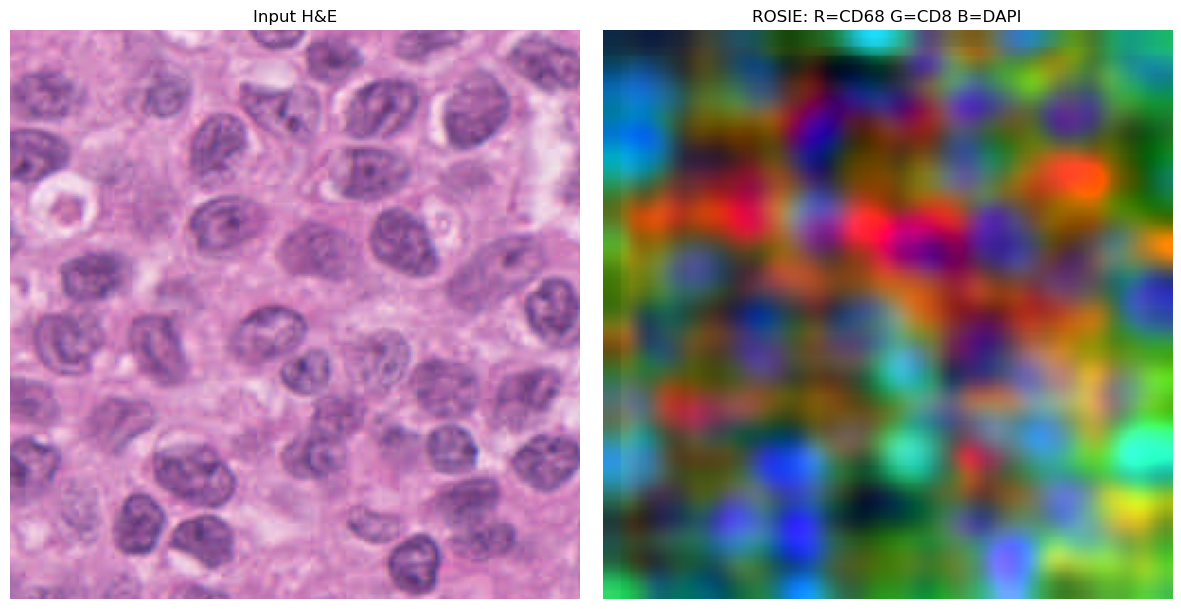

In [ ]:
def rgb_composite(data, r_idx, g_idx, b_idx, p_low=1, p_high=99.5):
    """Create RGB composite from 3 channels. Returns (H, W, 3) float in [0,1]."""
    r = normalize_channel(data[r_idx], p_low, p_high)
    g = normalize_channel(data[g_idx], p_low, p_high)
    b = normalize_channel(data[b_idx], p_low, p_high)
    return np.stack([r, g, b], axis=-1)

# Pick channels for R, G, B
r_idx = BIOMARKERS.index("CD68")
g_idx = BIOMARKERS.index("CD8")
b_idx = BIOMARKERS.index("DAPI")

data = load_rosie_tiff(tiff_path)
rgb = rgb_composite(data, r_idx, g_idx, b_idx)
he_img = load_he_image(tiff_path)
gt_data = load_gt_tiff(tiff_path)

ncols = 2 + (1 if gt_data is not None else 0)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))
axes = np.atleast_1d(axes)

axes[0].imshow(he_img if he_img is not None else np.zeros((*rgb.shape[:2], 3)))
axes[0].set_title("Input H&E")
axes[0].axis("off")

axes[1].imshow(rgb)
axes[1].set_title(f"ROSIE: R={BIOMARKERS[r_idx]} G={BIOMARKERS[g_idx]} B={BIOMARKERS[b_idx]}")
axes[1].axis("off")

if gt_data is not None:
    gt_rgb = rgb_composite(gt_data, r_idx, g_idx, b_idx)
    axes[2].imshow(gt_rgb)
    axes[2].set_title("Ground truth (multiplex)")
    axes[2].axis("off")
plt.tight_layout()
plt.show()

## 3. Multi-Marker Grid

H&E + several biomarkers side-by-side.

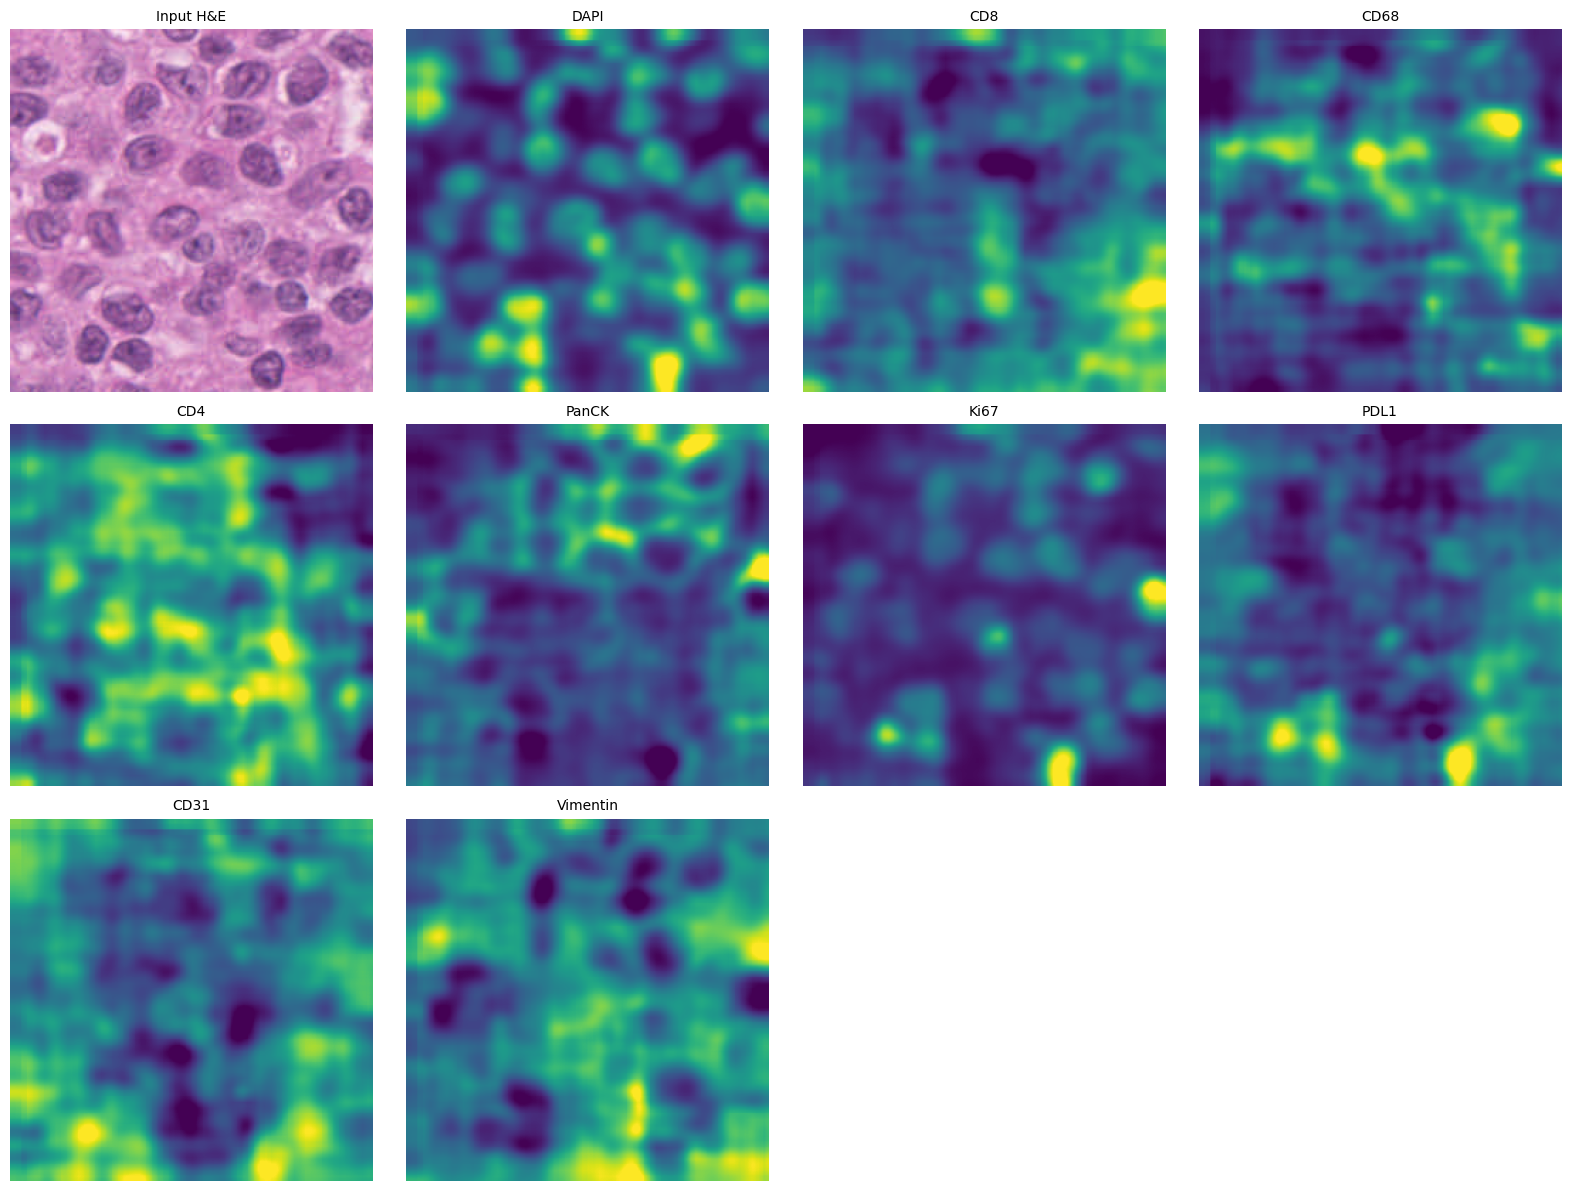

In [ ]:
# Select markers to show in grid
markers_to_show = ["DAPI", "CD8", "CD68", "CD4", "PanCK", "Ki67", "PDL1", "CD31", "Vimentin"]
indices = [BIOMARKERS.index(m) for m in markers_to_show if m in BIOMARKERS]
if len(indices) == 0:
    indices = list(range(9))

# Grid: H&E first, then markers
n = 1 + len(indices)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)
data = load_rosie_tiff(tiff_path)
he_img = load_he_image(tiff_path)

axes.flat[0].imshow(he_img if he_img is not None else np.zeros((256, 256, 3)))
axes.flat[0].set_title("Input H&E", fontsize=10)
axes.flat[0].axis("off")

for i, (ax, idx) in enumerate(zip(axes.flat[1:], indices)):
    ch = normalize_channel(data[idx])
    ax.imshow(ch, cmap="viridis")
    ax.set_title(BIOMARKERS[idx], fontsize=10)
    ax.axis("off")
for ax in axes.flat[1 + len(indices):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Preset RGB Combinations

H&E | ROSIE preset | (optional GT). Common marker combos.

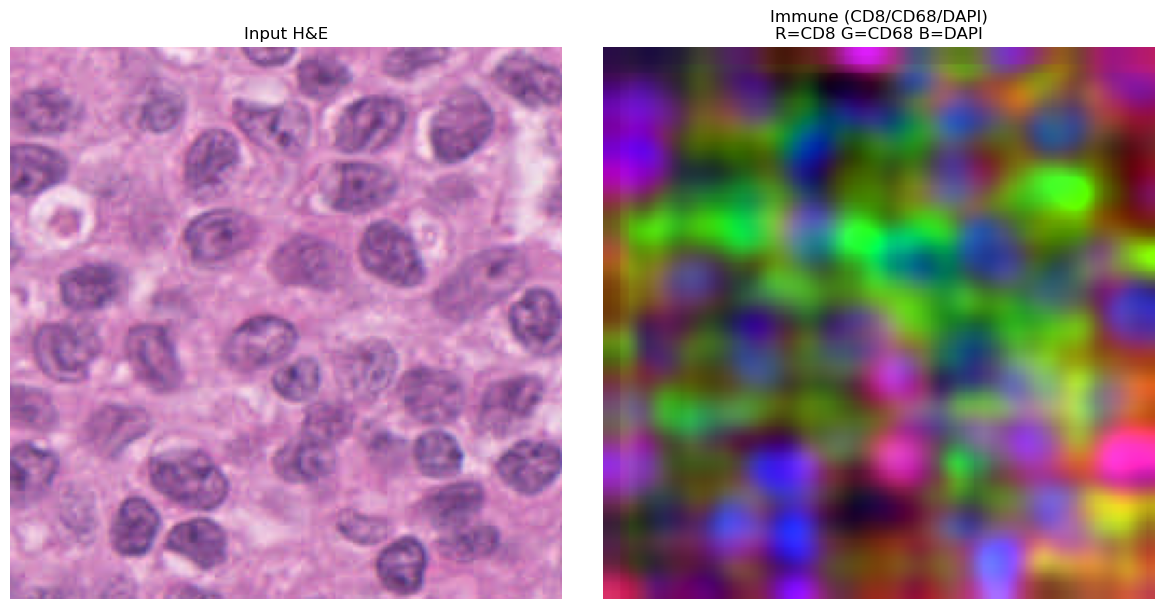

In [ ]:
presets = {
    "Immune (CD8/CD68/DAPI)": ("CD8", "CD68", "DAPI"),
    "T cells (CD4/CD8/DAPI)": ("CD4", "CD8", "DAPI"),
    "Epithelial (PanCK/EpCAM/DAPI)": ("PanCK", "EpCAM", "DAPI"),
    "Stroma (CD31/aSMA/Vimentin)": ("CD31", "aSMA", "Vimentin"),
    "Proliferation (Ki67/PCNA/DAPI)": ("Ki67", "PCNA", "DAPI"),
    "Checkpoint (PDL1/PD1/DAPI)": ("PDL1", "PD1", "DAPI"),
}
preset_name = "Immune (CD8/CD68/DAPI)"
r_name, g_name, b_name = presets[preset_name]
r_idx, g_idx, b_idx = BIOMARKERS.index(r_name), BIOMARKERS.index(g_name), BIOMARKERS.index(b_name)

data = load_rosie_tiff(tiff_path)
rgb = rgb_composite(data, r_idx, g_idx, b_idx)
he_img = load_he_image(tiff_path)
gt_data = load_gt_tiff(tiff_path)

ncols = 2 + (1 if gt_data is not None else 0)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))
axes = np.atleast_1d(axes)
axes[0].imshow(he_img if he_img is not None else np.zeros((*rgb.shape[:2], 3)))
axes[0].set_title("Input H&E")
axes[0].axis("off")
axes[1].imshow(rgb)
axes[1].set_title(f"{preset_name}\nR={r_name} G={g_name} B={b_name}")
axes[1].axis("off")
if gt_data is not None:
    gt_rgb = rgb_composite(gt_data, r_idx, g_idx, b_idx)
    axes[2].imshow(gt_rgb)
    axes[2].set_title("Ground truth")
    axes[2].axis("off")
plt.tight_layout()
plt.show()